# Debugging exercise: someone else's orbit code

## The situation

A former member of your group left you a short Python script that computes and plots **the orbit of a planet around its star**.
You would like to reuse it for your own project. Unfortunately, it "almost works":

* some parts make Python **crash** with an error message;
* other parts **run without complaint but give a wrong result**.

This is a very common situation in research: you will spend a lot of time using, adapting and fixing code written by others.
The second kind of bug is by far the most dangerous, because nothing warns you. The only defence is to **know what result to expect** and to **check it**.

Your job: make the code run *and* convince yourself that its results are physically correct.

## The physics in 5 minutes

A planet of negligible mass orbiting a star of mass $M_\star$ follows an **ellipse** with the star at one **focus**.
The ellipse is described by two numbers:

* the **semi-major axis** $a$ (the "size" of the orbit),
* the **eccentricity** $e$, with $0 \le e < 1$ ($e = 0$ is a circle; the closer to 1, the more elongated).

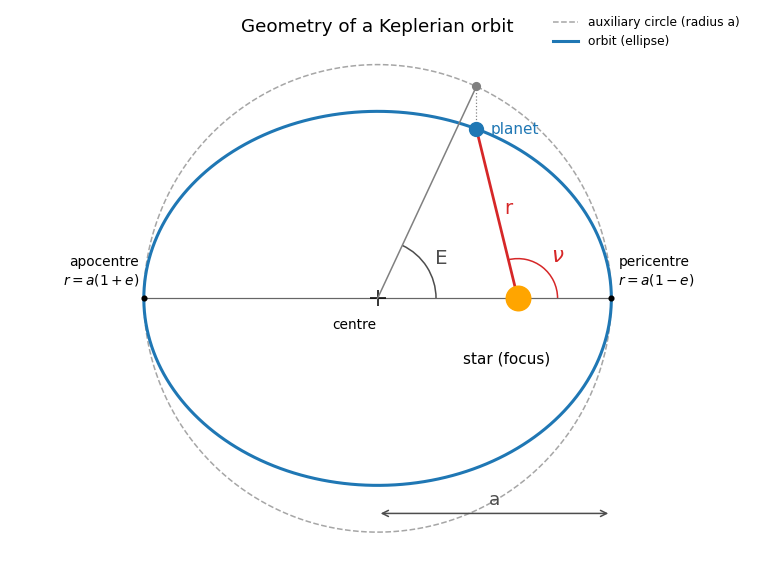

**1. How long is one orbit?** Kepler's third law gives the orbital period $T$:

$$ T = \sqrt{\frac{4\pi^2 a^3}{G M_\star}} \qquad (\text{all quantities in SI units}) $$

**2. Where is the planet at time $t$?** This takes three angles, all measured from the **pericentre** (the point closest to the star) and all in **radians**:

| Angle | Name | Meaning |
|---|---|---|
| $M$ | mean anomaly | a "fake" angle that grows uniformly with time: $M = 2\pi\, t / T$ (one full turn $= 2\pi$ per period) |
| $E$ | eccentric anomaly | angle seen from the **centre** of the ellipse, on the auxiliary circle (see figure) |
| $\nu$ | true anomaly | the **real** angle of the planet, seen from the **star** |

The recipe to go from time to position is:

1. $M = 2\pi\, t/T$
2. Solve **Kepler's equation** $\;E - e\sin E = M\;$ for $E$. There is no closed formula, so we iterate:
   start with $E_0 = M$, then repeat $E_{k+1} = M + e \sin E_k$ a few times.
3. $\nu = 2\arctan\!\left(\sqrt{\dfrac{1+e}{1-e}}\,\tan\dfrac{E}{2}\right)$
4. Distance to the star: $r = a\,(1 - e\cos E)$
5. Cartesian position (star at the origin): $x = r\cos\nu$, $\;y = r\sin\nu$

Repeating this for many times $t$ between $0$ and $T$ gives the points of the orbit.

**Sanity checks you can always use** (no computer needed!):

* The Earth ($a = 1$ AU, $e \approx 0.017$, $M_\star = 1\,M_\odot$) has $T = 1$ year and an almost circular orbit of radius 1 AU.
* The closest point is at $r = a(1-e)$ (pericentre, on the $+x$ axis), the farthest at $r = a(1+e)$ (apocentre, on the $-x$ axis).
* The star sits at a **focus**, not at the centre of the ellipse.

## Your mission

The code below contains **8 bugs**:

* **4 "crash" bugs**: Python stops with an error message (a *traceback*).
* **4 "silent" bugs**: the code runs, but the result is wrong. The ✅ **checkpoints** below each cell are there to catch them.

The code is split into small cells, one per step of the recipe above. Suggested strategy:

1. Run the cells **one at a time, from top to bottom**. Do not move on until the current cell runs *and* passes its checkpoint.
2. When Python crashes, read the traceback **from the bottom**: the last line tells you *what* went wrong, the arrow `---->` tells you *where*.
3. Fix **one bug at a time**, then re-run. After changing a parameter, re-run all the cells below it (or *Kernel → Restart & Run All*).
4. Use `print()` to inspect intermediate values when something looks suspicious.
5. Keep track of what you find in the **debugging log** at the end of the notebook.

Hints are hidden in the collapsible boxes: try without them first!

---
## Step 0: Imports

In [ ]:
import matplotlib.pyplot as plt

## Step 1: Parameters and physical constants

We first test the code on a case where we **know the answer**: the Earth around the Sun.

In [ ]:
# ---------------- User-defined parameters ----------------
star_mass   = 1.0      # mass of the star [M_Sun]
planet_mass = 1.0      # mass of the planet [M_Earth]
a = 1.0                # semi-major axis [AU]
e = 0.0167             # eccentricity, 0 <= e < 1 (0 = circle)

# ---------------- Physical constants (SI) ----------------
M_SUN   = 1.989e30     # [kg]
M_EARTH = 5.972e24     # [kg]
AU      = 1.496e11     # astronomical unit [m]
G = 0,000000000066743  # gravitational constant [m^3 kg^-1 s^-2]

# ---------------- Conversion to SI ----------------
star_mass_kg   = star_mass * M_SUN
planet_mass_kg = planet_mass * M_EARTH

✅ **Checkpoint 1**: the cell runs without error.

<details><summary>💡 Hint</summary>

How do you write a decimal number in Python? (Hint: not the way it is written in French!) And how do you write $6.67 \times 10^{-11}$ in a more readable way?
</details>

## Step 2: Orbital period (Kepler's third law)

In [ ]:
# Kepler's third law:  T = sqrt(4 pi^2 a^3 / (G M))
T = np.sqrt(4 * np.pi**2 * a**3 / G * star_mass_kg)

print(f"T = {T:.4e} s  =  {T / 86400:.2f} days  =  {T / (86400 * 365.25):.4f} yr")

✅ **Checkpoint 2**: for the Earth you must find $T \approx 1.00$ yr ($\approx 3.16\times10^{7}$ s, $\approx 365$ days).

<details><summary>💡 Hint 1</summary>

The first error is a `NameError`. Which module provides `np.sqrt` and `np.pi`, and where is it imported?
</details>

<details><summary>💡 Hint 2</summary>

Once it runs, the value is still wrong. There are **two independent problems** in the line computing `T`:
one about the order of operations (write the formula on paper: what is in the denominator?),
one about units (Kepler's law as written needs SI units: is `a` in metres?).
</details>

## Step 3: Solving Kepler's equation

This function takes the mean anomaly $M$ and returns the eccentric anomaly $E$ (recipe, step 2).

In [ ]:
def get_eccentric_anomaly(e, mean_anomaly, n_iter=10):
    """
    Solve Kepler's equation  E - e*sin(E) = M  by fixed-point iteration.

    Parameters
    ----------
    e : float
        Eccentricity of the orbit (0 <= e < 1).
    mean_anomaly : float
        Mean anomaly M [rad].
    n_iter : int
        Number of iterations.

    Returns
    -------
    E : float
        Eccentric anomaly [rad].
    """
    E = mean_anomaly                      # initial guess: E_0 = M
    for k in range(n_iter):
        E = mean_anomaly + e * np.sin(E)  # E_{k+1} = M + e sin(E_k)

✅ **Checkpoint 3**: test the function on cases where you know the answer:

* for a circle ($e = 0$), $E = M$ exactly;
* for $e = 0.5$, $M = 1$ rad, the solution is $E \approx 1.4987$ rad.

In [ ]:
# Test of the function
print(get_eccentric_anomaly(0.0, 1.0))    # expected: 1.0
print(get_eccentric_anomaly(0.5, 1.0))    # expected: about 1.4987

<details><summary>💡 Hint</summary>

The function computes something, but what does it give back to the caller? What do you get when you `print` the result?
</details>

## Step 4: Computing the positions along the orbit

We sample `n_points` times $t$ between $0$ and $T$ and apply the recipe (steps 1, 3, 4, 5) to each of them.

In [ ]:
n_points = 200         # number of intervals along the orbit

pos_x = ()             # x positions [AU]
pos_y = ()             # y positions [AU]

for i in range(n_points + 1):
    t = i * T / n_points                                # time since pericentre passage [s]
    mean_anomaly = 360 * t / T                          # recipe step 1
    E = get_eccentric_anomaly(e, mean_anomaly)          # recipe step 2
    true_anomaly = 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))   # step 3
    r = a * (1 - e * np.cos(E))                         # step 4: distance to the star [AU]

pos_x.append(r * np.cos(true_anomaly))                  # step 5
pos_y.append(r * np.sin(true_anomaly))

print(f"{len(pos_x)} positions computed")
print(f"min x = {min(pos_x):.4f} AU,  max x = {max(pos_x):.4f} AU")

✅ **Checkpoint 4**: you must obtain `n_points + 1` = 201 positions (the first and last points are both at $t=0$ and $t=T$, i.e. the same place).

<details><summary>💡 Hint 1</summary>

The error message says something about `append`. What type of object is created by `()`? Can it be modified after creation? Which Python type can?
</details>

<details><summary>💡 Hint 2</summary>

If you get only 1 point: in Python, what defines which lines are *inside* a `for` loop?
</details>

## Step 5: Plotting the orbit

In [ ]:
fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
ax.plot(pos_x, pos_y, color='tab:blue', label='planet')
ax.plot(0, 0, 'o', color='orange', markersize=12, label='star')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Orbit of the planet')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

✅ **Checkpoint 5**: for the Earth you should see an almost perfect **circle of radius 1 AU**, drawn once, as a smooth closed curve around the star.

<details><summary>💡 Hint</summary>

If the curve looks like a star or a scribble: the planet goes around many times, jumping by large angles between two points.
Look at how the mean anomaly is computed. In which unit do `np.sin`, `np.cos` and `np.tan` expect their argument? How much is one full turn in that unit?
</details>

## Step 6: The real case

Now that the code passes all the checks on the Earth, go back to **Step 1** and use the parameters your colleague was actually interested in:
a hot planet around a more massive star.

```python
star_mass   = 3.0     # [M_Sun]
planet_mass = 0.6     # [M_Earth]
a = 0.02              # [AU]
e = 0.4
```

Then re-run all the cells (*Kernel → Restart & Run All*) and check:

* ✅ $T \approx 0.60$ days (about 14 hours). Can you verify this with Kepler's third law in "solar-system units", $T[\mathrm{yr}] = \sqrt{a[\mathrm{AU}]^3 / M_\star[M_\odot]}$ ?
* ✅ The orbit is a clear ellipse. The pericentre is on the $+x$ axis at $x = a(1-e) = 0.012$ AU and the apocentre on the $-x$ axis at $x = -a(1+e) = -0.028$ AU.
* ✅ The star is at a focus of the ellipse, **not** at its centre.

## Debugging log

Fill in this table as you go (double-click to edit).

| # | Cell / line | What did you observe? (error message or wrong result) | Crash or silent? | Your fix |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |
| 6 | | | | |
| 7 | | | | |
| 8 | | | | |

## Questions for discussion

1. Which bugs were easier to find: the crash bugs or the silent ones? Why?
2. Which of the silent bugs would you have missed without the checkpoints? What would the consequence have been for your project?
3. The variable `planet_mass` is defined but never used. Is that a bug? (Hint: the exact law is $T^2 = 4\pi^2 a^3 / \big(G(M_\star + m_p)\big)$. How big is $m_p/M_\star$ here?)


## Going further (optional)

1. **Refactor**: put steps 2 to 4 in a single function `compute_orbit(star_mass, a, e, n_points=200)` returning `x, y` (and `T`).
   Use it to plot the orbits of Mercury ($a=0.387$ AU, $e=0.206$), Venus ($0.723$, $0.007$), Earth ($1.0$, $0.017$) and Mars ($1.524$, $0.093$) on the same figure.
2. **Use numpy arrays**: `np.sin`, `np.cos`, etc. work on whole arrays. Rewrite step 4 **without a `for` loop** over the points.
3. **Convergence**: `get_eccentric_anomaly` always does 10 iterations. Try $e = 0.95$: is it enough? Modify the function so that it iterates until $|E_{k+1} - E_k| < 10^{-10}$.